# 03 - Exploratory Data Analysis (EDA)
**Project:** DS Job Recommend  
**Branch:** `feature/visualization`  
**Dataset:** `data/processed/postings_clean.csv`  

---
### TABLE OF CONTENTS
1. **Environment Setup & Data Loading**
2. **Univariate Analysis** (Numerical & Categorical)
3. **Feature ↔ Feature Analysis** (Correlation & Multicollinearity)
4. **Feature ↔ Target Analysis** (Group Comparison)
5. **Categorical ↔ Numerical Analysis**
6. **Categorical ↔ Categorical Analysis** (Crosstab)
7. **Multivariate Analysis** (Scatter Matrix)
8. **Outlier Analysis & Log Transformation**
9. **Class Imbalance Analysis & Modeling Recommendations**
10. **Skill Analysis**
11. **Text Analysis**
12. **Business Insights & Executive Dashboard**
---

## 1. Environment Setup & Data Loading

In [250]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix
warnings.filterwarnings("ignore")

TARGET = 'formatted_experience_level'

In [251]:
from pathlib import Path
import sys

ROOT_DIR = Path('__file__').resolve().parent.parent if '__file__' in locals() else Path.cwd().parent
if str(ROOT_DIR) not in sys.path:
    sys.path.append(str(ROOT_DIR))

if (ROOT_DIR / 'data' / 'processed').exists():
    PROCESSED = ROOT_DIR / 'data' / 'processed'
elif Path('../data/processed').exists():
    PROCESSED = Path('../data/processed')
else:
    PROCESSED = Path('data/processed')

df = pd.read_csv(PROCESSED / 'postings_clean.csv', low_memory=False)
print(f'Dataset: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(df.columns.tolist())
print(df.head())
print(df.tail())

Dataset: 123,849 rows x 31 columns
['job_id', 'company_name', 'title', 'description', 'max_salary', 'pay_period', 'location', 'company_id', 'views', 'med_salary', 'min_salary', 'formatted_work_type', 'applies', 'original_listed_time', 'remote_allowed', 'job_posting_url', 'application_url', 'application_type', 'expiry', 'closed_time', 'formatted_experience_level', 'skills_desc', 'listed_time', 'posting_domain', 'sponsored', 'work_type', 'currency', 'compensation_type', 'normalized_salary', 'zip_code', 'fips']
     job_id            company_name  \
0    921716   Corcoran Sawyer Smith   
1   1829192                     NaN   
2  10998357   The National Exemplar   
3  23221523  Abrams Fensterman, LLP   
4  35982263                     NaN   

                                               title  \
0                              Marketing Coordinator   
1                  Mental Health Therapist/Counselor   
2                        Assitant Restaurant Manager   
3  Senior Elder Law / Trust

In [252]:
df.info()
df.describe(include='all')

<class 'pandas.DataFrame'>
RangeIndex: 123849 entries, 0 to 123848
Data columns (total 31 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   job_id                      123849 non-null  int64  
 1   company_name                122130 non-null  str    
 2   title                       123849 non-null  str    
 3   description                 123842 non-null  str    
 4   max_salary                  29793 non-null   float64
 5   pay_period                  36073 non-null   str    
 6   location                    123849 non-null  str    
 7   company_id                  122132 non-null  float64
 8   views                       122160 non-null  float64
 9   med_salary                  6266 non-null    float64
 10  min_salary                  29793 non-null   float64
 11  formatted_work_type         123849 non-null  str    
 12  applies                     23320 non-null   float64
 13  original_listed_time     

,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,...,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips
count,1.238490e+05,122130,123849,123842,2.979300e+04,36073,123849,1.221320e+05,122160.000000,6266.000000,...,2439,1.238490e+05,83881,123849.0,123849,36073,36073,3.605900e+04,102977.000000,96434.000000
unique,NaN,24423,72051,107550,NaN,5,8526,NaN,NaN,NaN,...,2211,NaN,4443,NaN,7,6,1,NaN,NaN,NaN
top,NaN,Liberty Healthcare and Rehabilitation Services,Sales Manager,Position Summary: Our Sales Manager has managi...,NaN,YEARLY,United States,NaN,NaN,NaN,...,This position requires the following skills: E...,NaN,www.click2apply.net,NaN,FULL_TIME,USD,BASE_SALARY,NaN,NaN,NaN
freq,NaN,1108,673,475,NaN,20298,8125,NaN,NaN,NaN,...,28,NaN,3811,NaN,98814,36058,36073,NaN,NaN,NaN
mean,3.896402e+09,NaN,NaN,NaN,9.193942e+04,NaN,NaN,1.220401e+07,14.618247,22064.808940,...,NaN,1.713204e+12,NaN,0.0,NaN,NaN,NaN,9.972543e+04,50400.491887,28713.879887
std,8.404355e+07,NaN,NaN,NaN,7.011101e+05,NaN,NaN,2.554143e+07,85.903598,52303.851683,...,NaN,3.989122e+08,NaN,0.0,NaN,NaN,NaN,5.432585e+05,30252.232515,16015.929825
min,9.217160e+05,NaN,NaN,NaN,1.000000e+00,NaN,NaN,1.009000e+03,1.000000,9.000000,...,NaN,1.711317e+12,NaN,0.0,NaN,NaN,NaN,1.200000e+02,1001.000000,1003.000000
25%,3.894587e+09,NaN,NaN,NaN,4.828000e+01,NaN,NaN,1.435200e+04,3.000000,19.000000,...,NaN,1.712886e+12,NaN,0.0,NaN,NaN,NaN,5.200000e+04,24112.000000,13121.000000
50%,3.901998e+09,NaN,NaN,NaN,8.000000e+04,NaN,NaN,2.269650e+05,4.000000,25.530000,...,NaN,1.713408e+12,NaN,0.0,NaN,NaN,NaN,8.250000e+04,48059.000000,29183.000000
75%,3.904707e+09,NaN,NaN,NaN,1.400000e+05,NaN,NaN,8.047188e+06,8.000000,2523.250000,...,NaN,1.713484e+12,NaN,0.0,NaN,NaN,NaN,1.250000e+05,78201.000000,42077.000000


In [253]:
print('=== MISSING VALUES ===')
print(df.isnull().sum())
print('\n=== MISSING RATIO (%) ===')
print((df.isnull().sum() / df.shape[0]) * 100)
print(f'\n=== DUPLICATE RATIO: {(df.duplicated().sum() / df.shape[0]) * 100:.2f}% ===')

=== MISSING VALUES ===
job_id                             0
company_name                    1719
title                              0
description                        7
max_salary                     94056
pay_period                     87776
location                           0
company_id                      1717
views                           1689
med_salary                    117583
min_salary                     94056
formatted_work_type                0
applies                       100529
original_listed_time               0
remote_allowed                     0
job_posting_url                    0
application_url                36665
application_type                   0
expiry                             0
closed_time                   122776
formatted_experience_level     29409
skills_desc                   121410
listed_time                        0
posting_domain                 39968
sponsored                          0
work_type                          0
currency       

## 2. Univariate Analysis (Numerical & Categorical)

### 2.1 Numerical Features (Histplot + KDE)

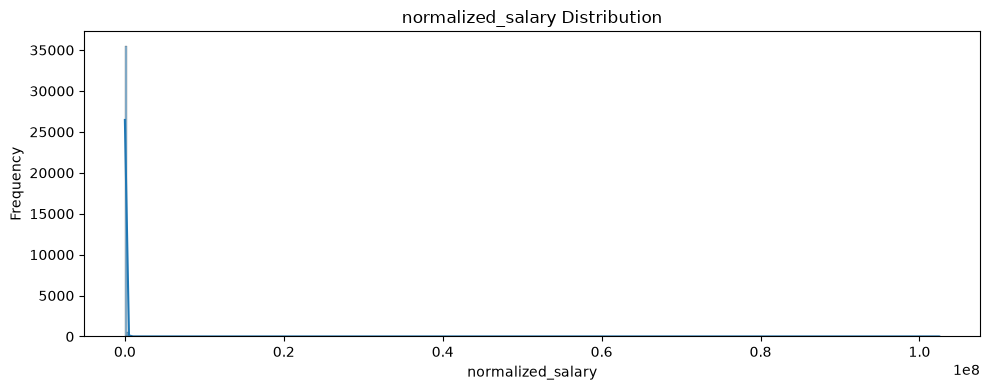

>>> normalized_salary:
    Spread from 120 to 102,500,000
    Concentrated in range 52,000 - 125,000 (Q1-Q3)
    Mean: 99,725 | Median: 82,500



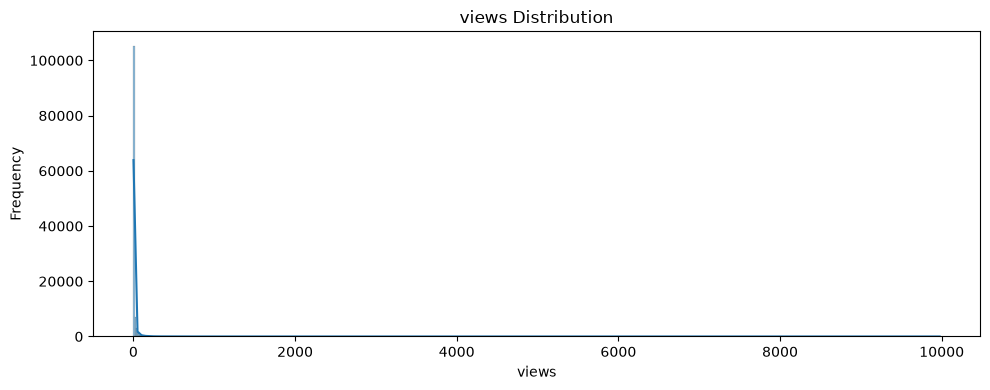

>>> views:
    Spread from 1 to 9,975
    Concentrated in range 3 - 8 (Q1-Q3)
    Mean: 15 | Median: 4



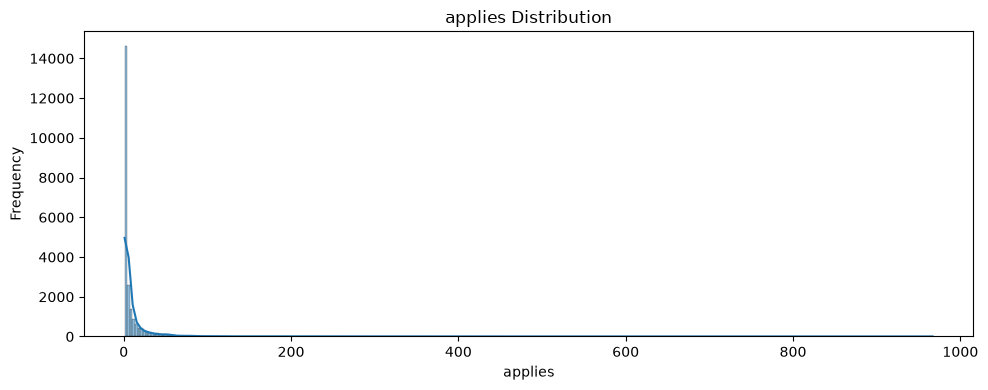

>>> applies:
    Spread from 1 to 967
    Concentrated in range 1 - 8 (Q1-Q3)
    Mean: 11 | Median: 3



In [254]:
NUM_COLS = [c for c in ['normalized_salary', 'views', 'applies']
            if c in df.columns]

for col in NUM_COLS:
    data = df[col].dropna()
    
    plt.figure(figsize=(10, 4))
    sns.histplot(data, kde=True)
    plt.title(f'{col} Distribution')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()
    
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    print(f'>>> {col}:')
    print(f'    Spread from {data.min():,.0f} to {data.max():,.0f}')
    print(f'    Concentrated in range {q1:,.0f} - {q3:,.0f} (Q1-Q3)')
    print(f'    Mean: {data.mean():,.0f} | Median: {data.median():,.0f}')
    print()

### 2.2 Categorical Features (Countplot)

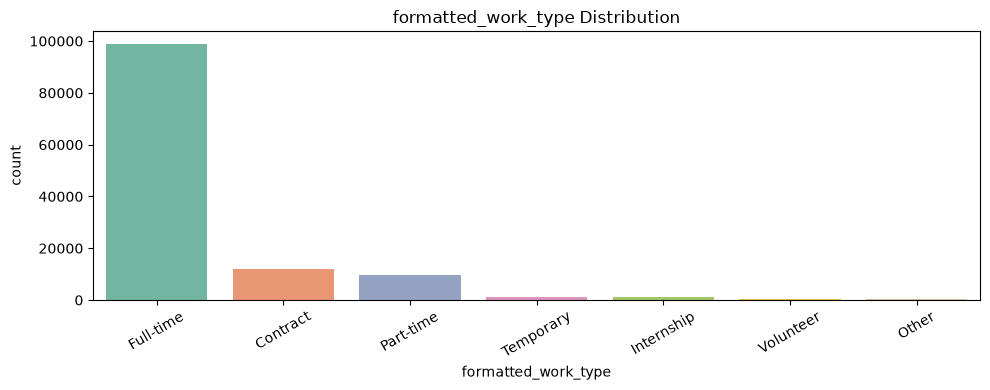

    Full-time: 79.8%
    Contract: 9.8%
    Part-time: 7.8%
    Temporary: 1.0%
    Internship: 0.8%
    Volunteer: 0.5%
    Other: 0.4%



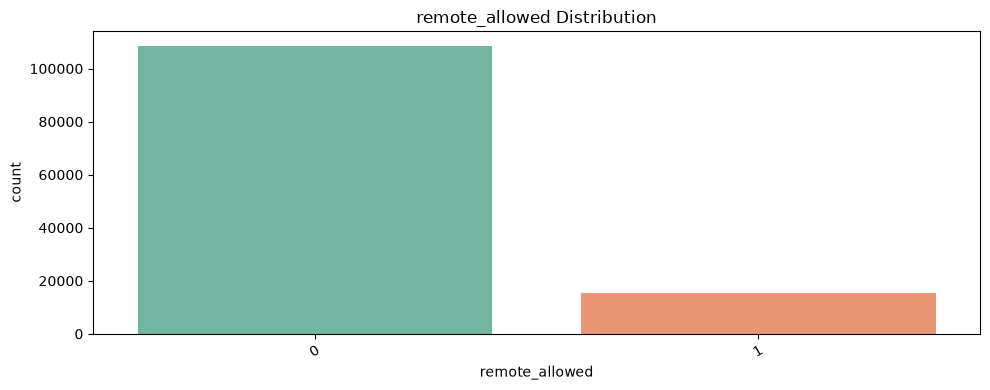

    0: 87.7%
    1: 12.3%



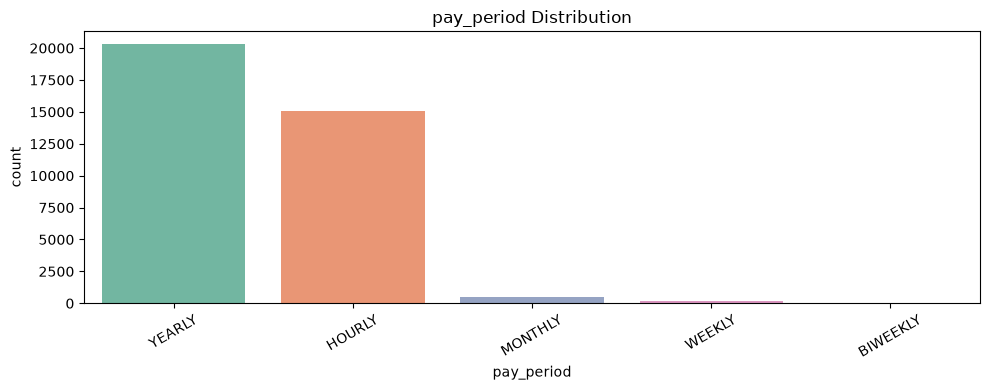

    YEARLY: 16.4%
    HOURLY: 12.2%
    MONTHLY: 0.4%
    WEEKLY: 0.1%
    BIWEEKLY: 0.0%



In [255]:
CAT_COLS = [c for c in ['formatted_work_type', 'remote_allowed', 'pay_period']
            if c in df.columns]

for col in CAT_COLS:
    plt.figure(figsize=(10, 4))
    order = df[col].value_counts().index
    sns.countplot(x=col, data=df, order=order, palette='Set2')
    plt.title(f'{col} Distribution')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()
    
    counts = df[col].value_counts()
    pct = (counts / len(df) * 100).round(1)
    for val, p in pct.items():
        print(f'    {val}: {p}%')
    print()

## 3. Feature ↔ Feature Analysis (Correlation & Multicollinearity)

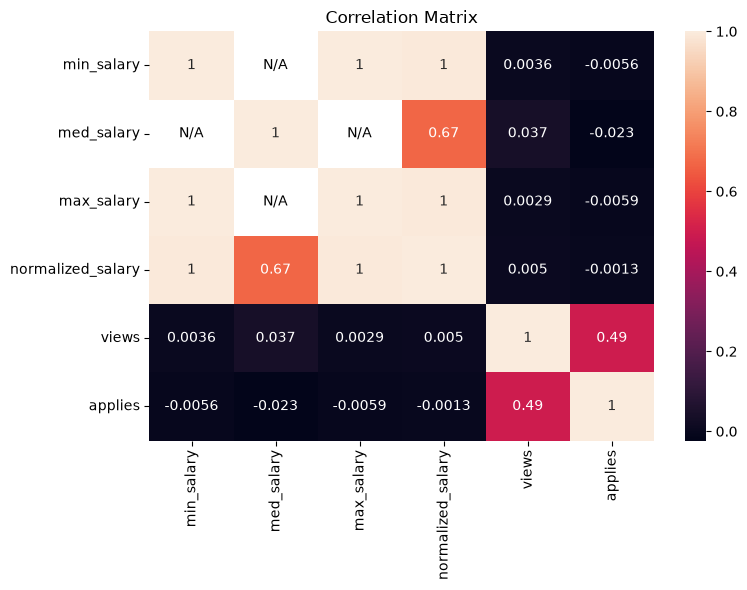

>>> Multicollinearity check:


In [256]:
all_num = [c for c in ['min_salary', 'med_salary', 'max_salary',
                        'normalized_salary', 'views', 'applies']
           if c in df.columns]

if len(all_num) >= 2:
    corr = df[all_num].corr(numeric_only=True)
    plt.figure(figsize=(8, 6))
    ax = sns.heatmap(corr, annot=True)
    for i in range(len(all_num)):
        for j in range(len(all_num)):
            if pd.isna(corr.iloc[i, j]):
                ax.text(j + 0.5, i + 0.5, 'N/A', 
                        ha='center', va='center', color='black')
    plt.title('Correlation Matrix')
    plt.tight_layout()
    plt.show()
    
    print('>>> Multicollinearity check:')
    for i in range(len(all_num)):
        for j in range(i+1, len(all_num)):
            r = corr.iloc[i, j]
            if pd.isna(r):
                continue
            if abs(r) > 0.9:
                print(f'    WARNING: {all_num[i]} <-> {all_num[j]}: r = {r:.3f} (very high!)')
            elif abs(r) > 0.7:
                print(f'    NOTE: {all_num[i]} <-> {all_num[j]}: r = {r:.3f} (high)')

## 4. Feature ↔ Target Analysis (Group Comparison)

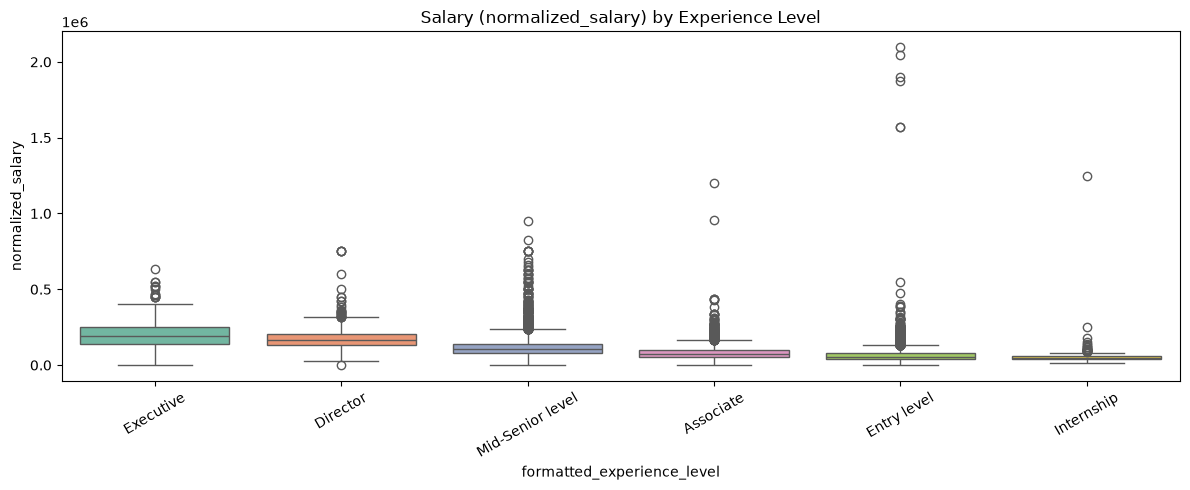

In [257]:
sal_col = next((c for c in ['normalized_salary', 'med_salary'] if c in df.columns), None)

if sal_col and TARGET in df.columns:
    plot_df = df[[TARGET, sal_col]].dropna()
    order = plot_df.groupby(TARGET)[sal_col].median().sort_values(ascending=False).index
    
    plt.figure(figsize=(12, 5))
    sns.boxplot(data=plot_df, x=TARGET, y=sal_col, order=order, palette='Set2')
    plt.title(f'Salary ({sal_col}) by Experience Level')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

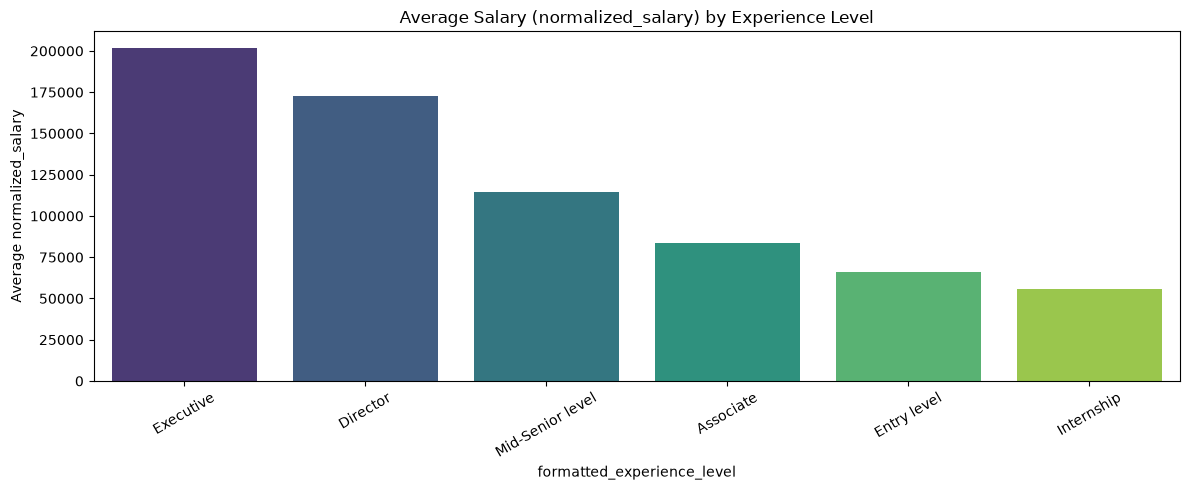

>>> Average salary by level:
    Executive: $201,789
    Director: $172,832
    Mid-Senior level: $114,406
    Associate: $83,648
    Entry level: $66,325
    Internship: $55,458


In [258]:
if sal_col and TARGET in df.columns:
    avg_salary = df.groupby(TARGET)[sal_col].mean().sort_values(ascending=False)
    
    plt.figure(figsize=(12, 5))
    sns.barplot(x=avg_salary.index, y=avg_salary.values, palette='viridis')
    plt.title(f'Average Salary ({sal_col}) by Experience Level')
    plt.ylabel(f'Average {sal_col}')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()
    
    print('>>> Average salary by level:')
    for level, sal in avg_salary.items():
        print(f'    {level}: ${sal:,.0f}')

## 5. Categorical ↔ Numerical Analysis

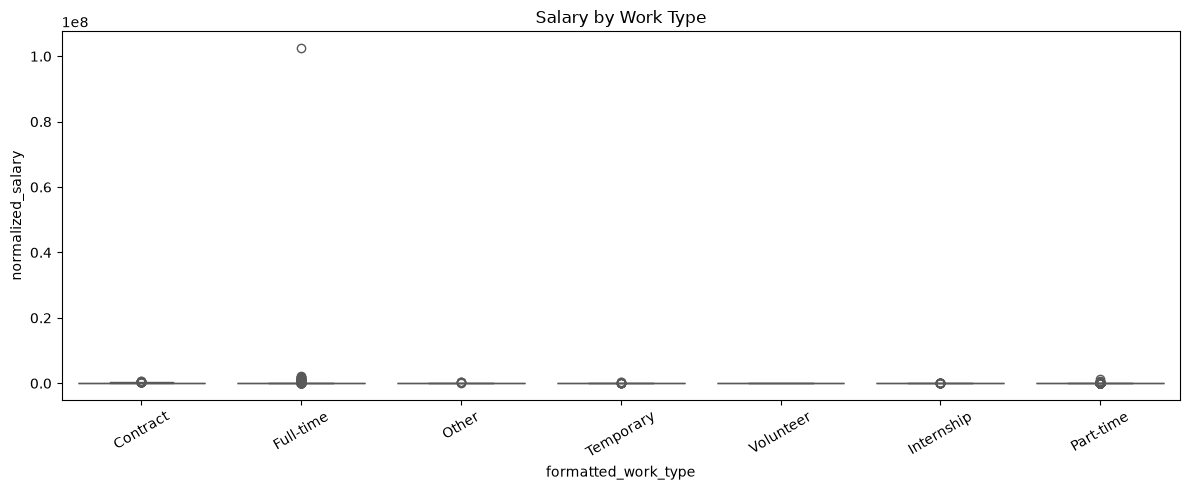

In [259]:
if sal_col and 'formatted_work_type' in df.columns:
    plot_df = df[['formatted_work_type', sal_col]].dropna()
    order = plot_df.groupby('formatted_work_type')[sal_col].median().sort_values(ascending=False).index
    
    plt.figure(figsize=(12, 5))
    sns.boxplot(data=plot_df, x='formatted_work_type', y=sal_col, order=order, palette='Set2')
    plt.title(f'Salary by Work Type')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

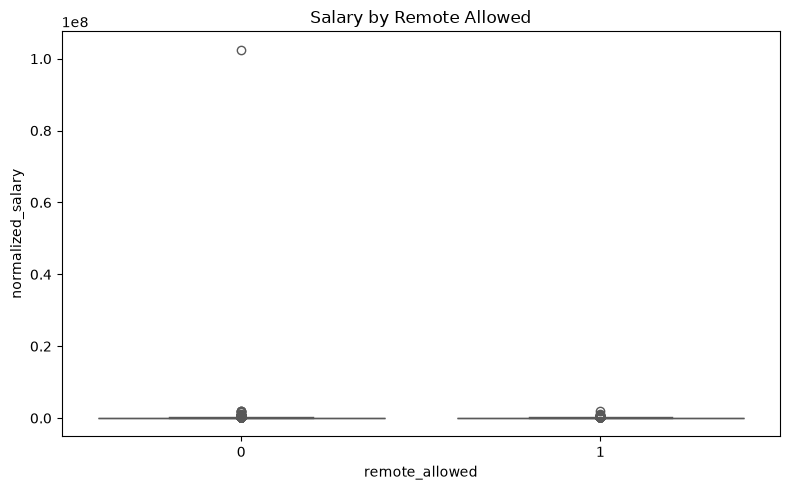

In [260]:
if sal_col and 'remote_allowed' in df.columns:
    plot_df = df[['remote_allowed', sal_col]].dropna()
    
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=plot_df, x='remote_allowed', y=sal_col, palette='Set2')
    plt.title('Salary by Remote Allowed')
    plt.tight_layout()
    plt.show()

## 6. Categorical ↔ Categorical Analysis (Crosstab)

=== Work Type by Experience Level (%) ===
formatted_work_type         Contract  Full-time  Internship  Other  Part-time  \
formatted_experience_level                                                      
Associate                       14.1       76.9         0.1    0.0        3.2   
Director                         3.6       93.9         0.1    0.2        1.7   
Entry level                      4.7       80.1         0.2    0.5       13.5   
Executive                        3.8       91.9         0.0    0.6        2.8   
Internship                       0.4       53.3        34.0    0.4        9.6   
Mid-Senior level                12.4       80.8         0.1    0.3        5.2   

formatted_work_type         Temporary  Volunteer  
formatted_experience_level                        
Associate                         1.2        4.4  
Director                          0.4        0.0  
Entry level                       1.0        0.0  
Executive                         0.7        0.2  
Int

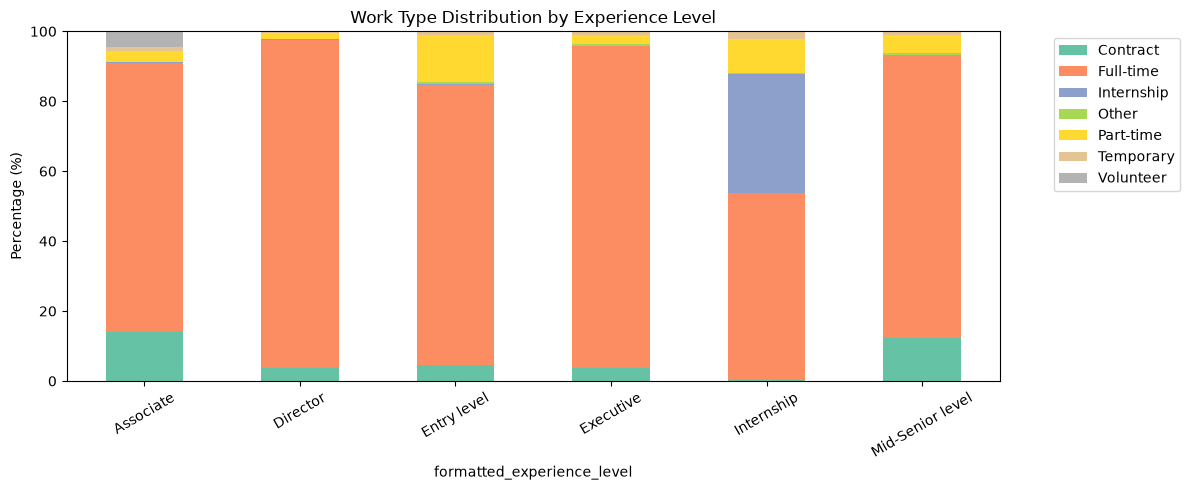

In [261]:
if TARGET in df.columns and 'formatted_work_type' in df.columns:
    ct = pd.crosstab(df[TARGET], df['formatted_work_type'], normalize='index') * 100
    print('=== Work Type by Experience Level (%) ===')
    print(ct.round(1))
    
    ct.plot(kind='bar', stacked=True, figsize=(12, 5), colormap='Set2')
    plt.title('Work Type Distribution by Experience Level')
    plt.ylabel('Percentage (%)')
    plt.xticks(rotation=30)
    plt.legend(bbox_to_anchor=(1.05, 1))
    plt.tight_layout()
    plt.show()

=== Remote Allowed by Experience Level (%) ===
remote_allowed                 0     1
formatted_experience_level            
Associate                   88.0  12.0
Director                    82.1  17.9
Entry level                 94.7   5.3
Executive                   81.3  18.7
Internship                  93.8   6.2
Mid-Senior level            84.6  15.4


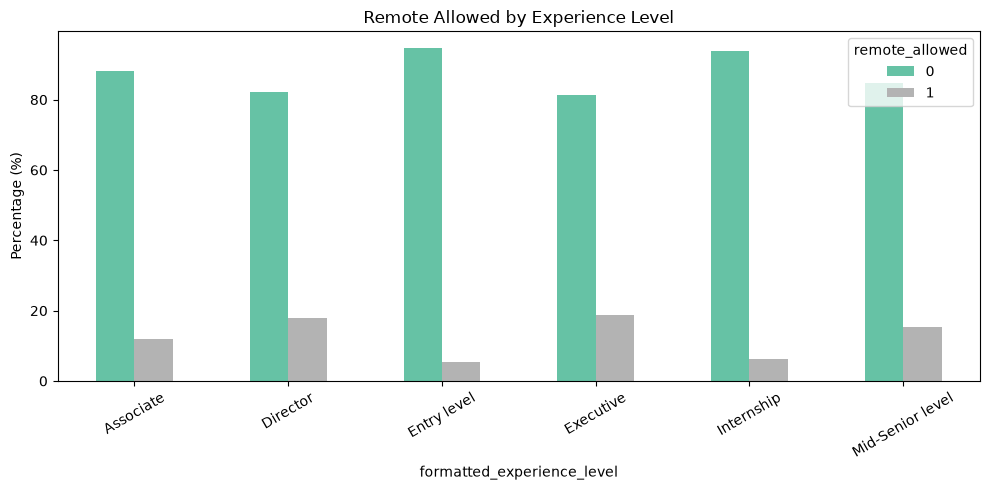

In [262]:
if TARGET in df.columns and 'remote_allowed' in df.columns:
    ct2 = pd.crosstab(df[TARGET], df['remote_allowed'], normalize='index') * 100
    print('=== Remote Allowed by Experience Level (%) ===')
    print(ct2.round(1))
    
    ct2.plot(kind='bar', figsize=(10, 5), colormap='Set2')
    plt.title('Remote Allowed by Experience Level')
    plt.ylabel('Percentage (%)')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

## 7. Multivariate Analysis (Scatter Matrix)

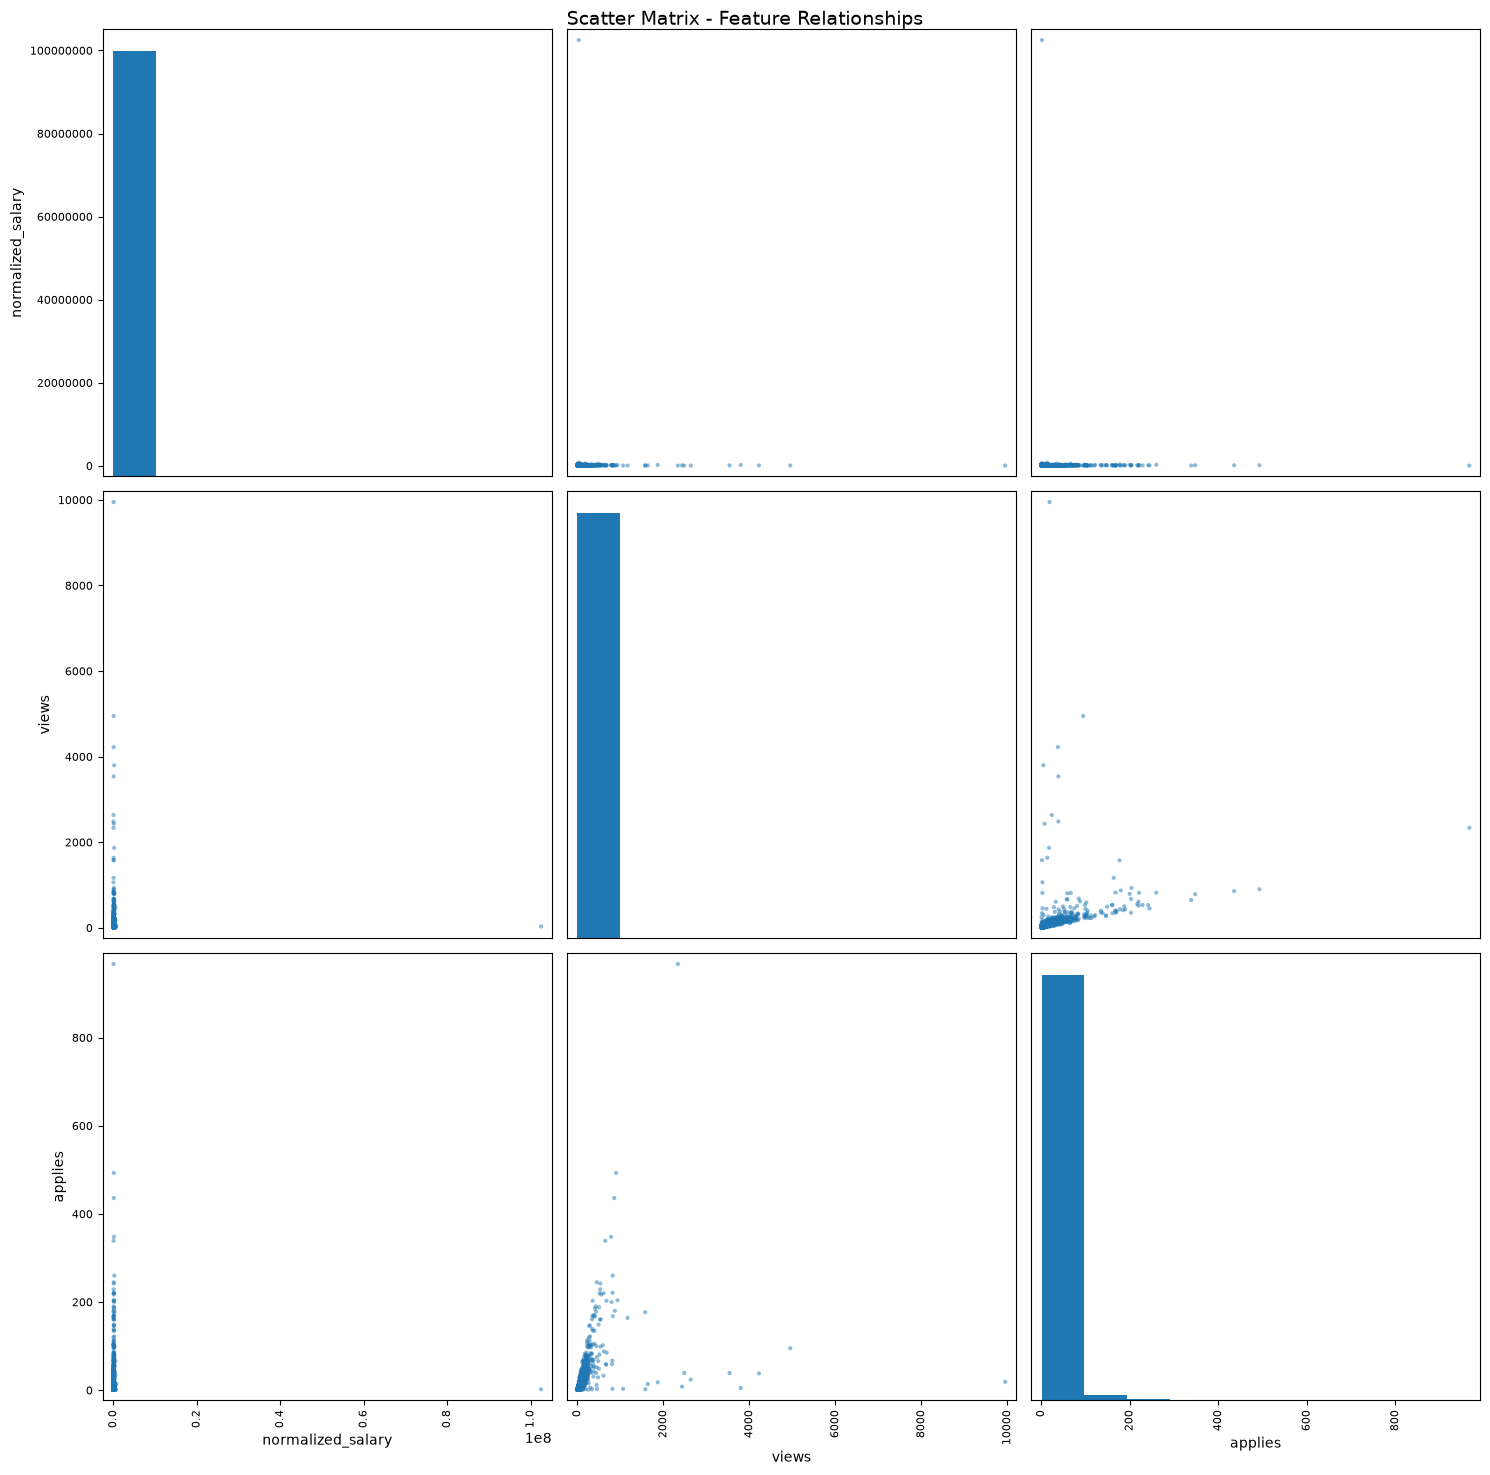

In [263]:
scatter_cols = [c for c in ['normalized_salary', 'views', 'applies']
                if c in df.columns]

if len(scatter_cols) >= 2:
    sample = df[scatter_cols].dropna()
    if len(sample) > 3000:
        sample = sample.sample(3000, random_state=42)
    scatter_matrix(sample, figsize=(15, 15))
    plt.suptitle('Scatter Matrix - Feature Relationships', fontsize=14)
    plt.tight_layout()
    plt.show()

## 8. Outlier Analysis & Log Transformation

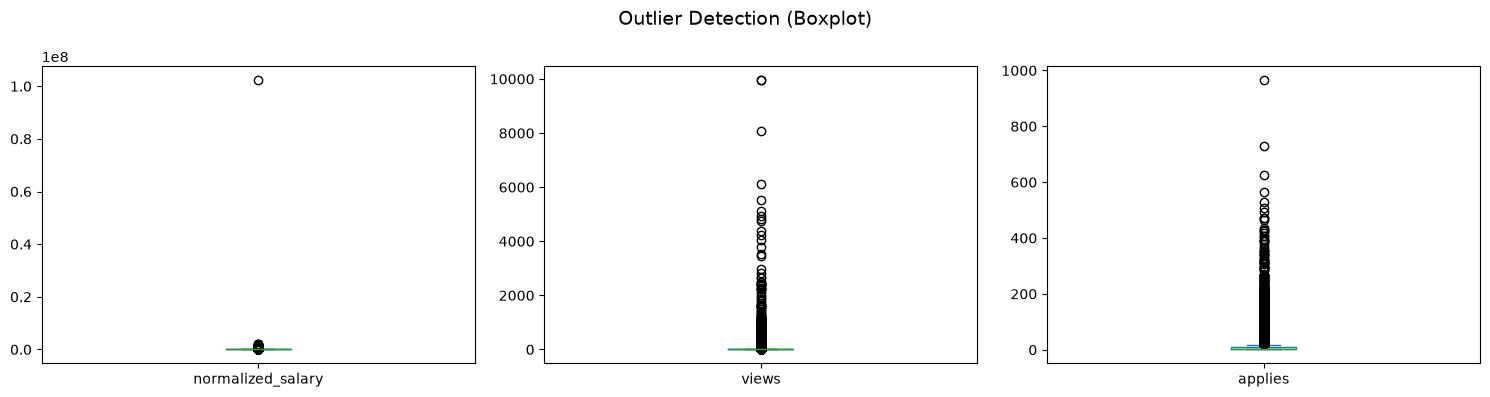

In [264]:
if NUM_COLS:
    n = len(NUM_COLS)
    ncols = min(n, 3)
    nrows = (n + ncols - 1) // ncols
    
    df[NUM_COLS].plot(kind='box', subplots=True, layout=(nrows, ncols),
                      figsize=(5*ncols, 4*nrows))
    plt.suptitle('Outlier Detection (Boxplot)', fontsize=14)
    plt.tight_layout()
    plt.show()

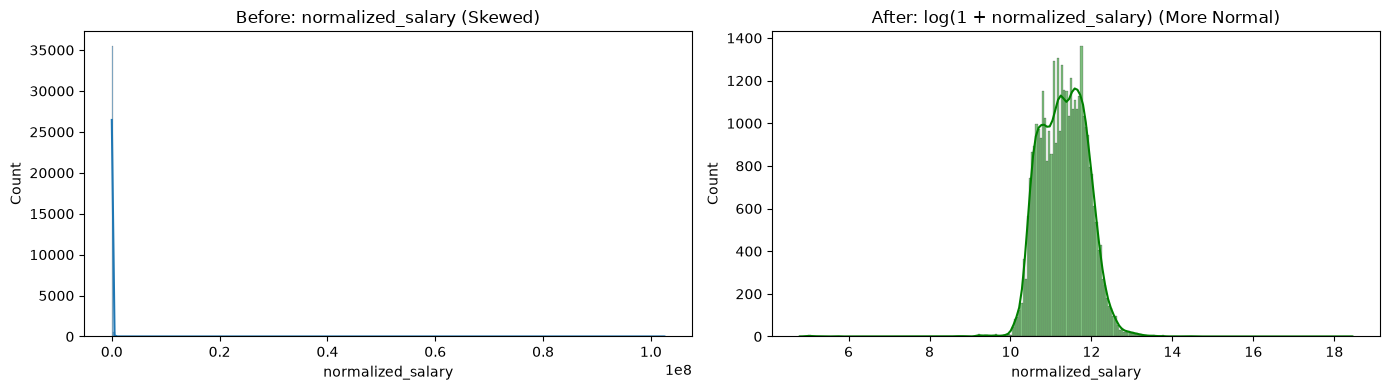

>>> Skewness before log: 185.75
>>> Skewness after log:  -0.61


In [265]:
if sal_col and sal_col in df.columns:
    data = df[sal_col].dropna()
    data_log = np.log1p(data)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    sns.histplot(data, kde=True, ax=axes[0])
    axes[0].set_title(f'Before: {sal_col} (Skewed)')
    
    sns.histplot(data_log, kde=True, ax=axes[1], color='green')
    axes[1].set_title(f'After: log(1 + {sal_col}) (More Normal)')
    
    plt.tight_layout()
    plt.show()
    
    print(f'>>> Skewness before log: {data.skew():.2f}')
    print(f'>>> Skewness after log:  {data_log.skew():.2f}')

## 9. Class Imbalance Analysis & Modeling Recommendations

=== TARGET DISTRIBUTION ===
formatted_experience_level
Mid-Senior level    41489
Entry level         36708
Associate            9826
Director             3746
Internship           1449
Executive            1222
Name: count, dtype: int64

=== Imbalance Ratio: 41489 / 1222 = 34.0 : 1 ===


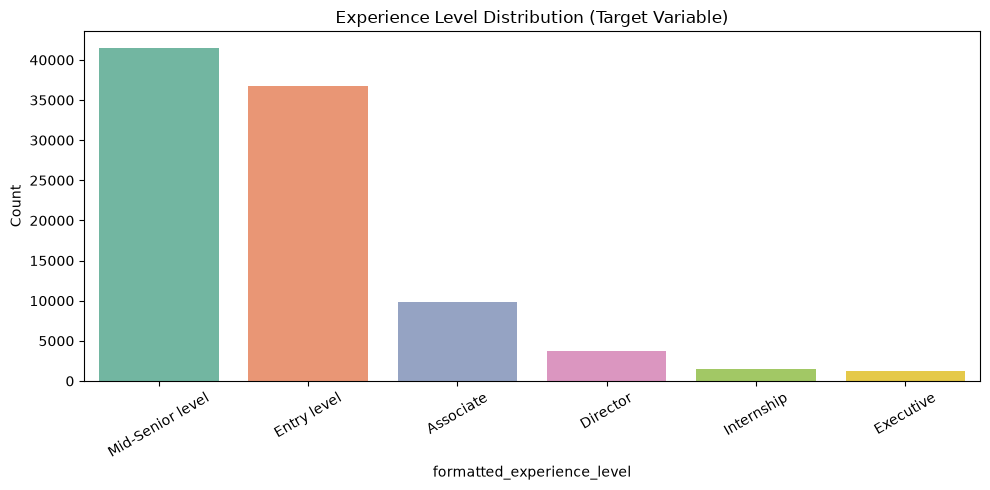


>>> Modeling Recommendations:
    1. Use Stratified K-Fold to preserve class ratios
    2. Use F1-Macro or Balanced Accuracy instead of Accuracy
    3. Apply SMOTE or class_weight="balanced" to handle imbalance


In [266]:
if TARGET in df.columns:
    counts = df[TARGET].value_counts()
    print('=== TARGET DISTRIBUTION ===')
    print(counts)
    print(f'\n=== Imbalance Ratio: {counts.max()} / {counts.min()} = {counts.max()/counts.min():.1f} : 1 ===')
    
    plt.figure(figsize=(10, 5))
    sns.countplot(x=TARGET, data=df.dropna(subset=[TARGET]),
                  order=counts.index, palette='Set2')
    plt.title('Experience Level Distribution (Target Variable)')
    plt.ylabel('Count')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()
    
    print('\n>>> Modeling Recommendations:')
    print('    1. Use Stratified K-Fold to preserve class ratios')
    print('    2. Use F1-Macro or Balanced Accuracy instead of Accuracy')
    print('    3. Apply SMOTE or class_weight="balanced" to handle imbalance')

## 10. Skill Analysis

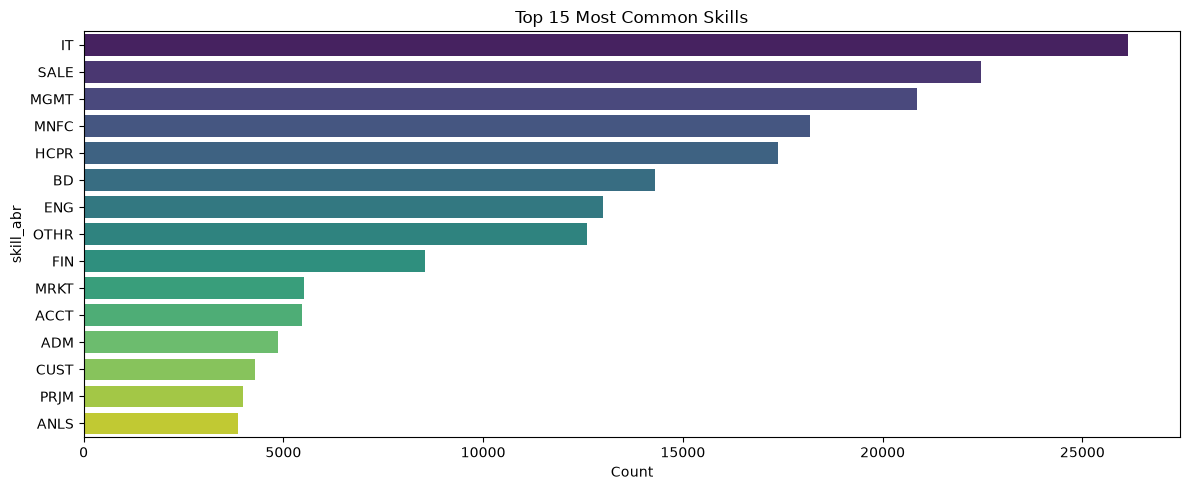


>>> Top 5 skills by Experience Level:

  Associate:
    - SALE: 1590
    - IT: 1270
    - OTHR: 1039
    - FIN: 1027
    - ADM: 947

  Director:
    - SALE: 888
    - BD: 682
    - MGMT: 620
    - IT: 507
    - FIN: 440

  Entry level:
    - MGMT: 9218
    - MNFC: 8436
    - IT: 6595
    - HCPR: 6127
    - SALE: 5900

  Executive:
    - SALE: 329
    - BD: 284
    - MGMT: 282
    - FIN: 190
    - IT: 146

  Internship:
    - IT: 390
    - ENG: 247
    - MGMT: 194
    - TRNG: 188
    - SALE: 184

  Mid-Senior level:
    - IT: 10169
    - SALE: 6962
    - HCPR: 5660
    - MGMT: 5410
    - ENG: 4866


In [267]:
skills_path = PROCESSED / 'job_skills_clean.csv'
if skills_path.exists():
    job_skills = pd.read_csv(skills_path)
    skill_col = next((c for c in ['skill_abr', 'skill_name', 'skill'] if c in job_skills.columns), None)
    
    if skill_col:
        top_skills = job_skills[skill_col].value_counts().head(15)
        
        plt.figure(figsize=(12, 5))
        sns.barplot(x=top_skills.values, y=top_skills.index, palette='viridis')
        plt.title('Top 15 Most Common Skills')
        plt.xlabel('Count')
        plt.tight_layout()
        plt.show()
        
        # Skills by experience level
        id_col = next((c for c in ['job_id', 'jobId'] 
                       if c in job_skills.columns and c in df.columns), None)
        if id_col and TARGET in df.columns:
            merged = job_skills.merge(df[[id_col, TARGET]].dropna(), on=id_col)
            print('\n>>> Top 5 skills by Experience Level:')
            for level in sorted(merged[TARGET].unique()):
                top5 = merged[merged[TARGET] == level][skill_col].value_counts().head(5)
                print(f'\n  {level}:')
                for skill, cnt in top5.items():
                    print(f'    - {skill}: {cnt}')
else:
    print('job_skills_clean.csv not found, skipping skill analysis.')

## 11. Text Analysis

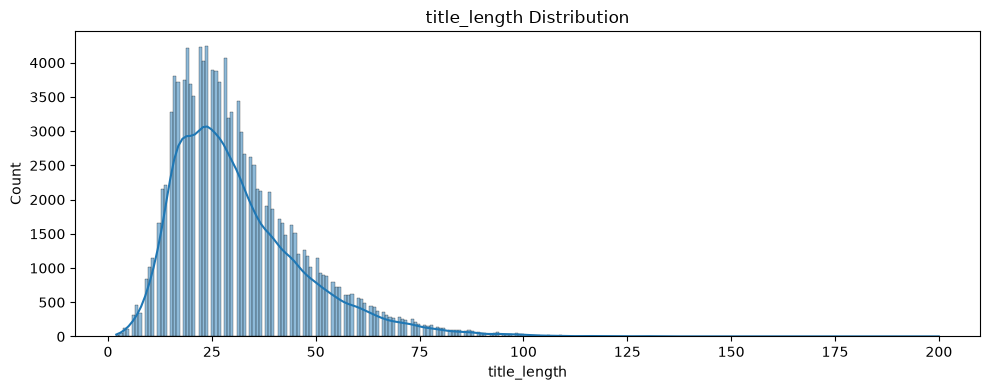

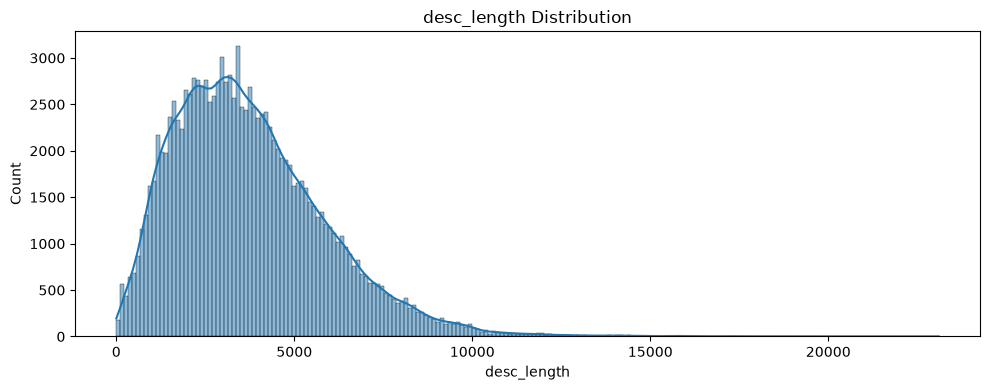

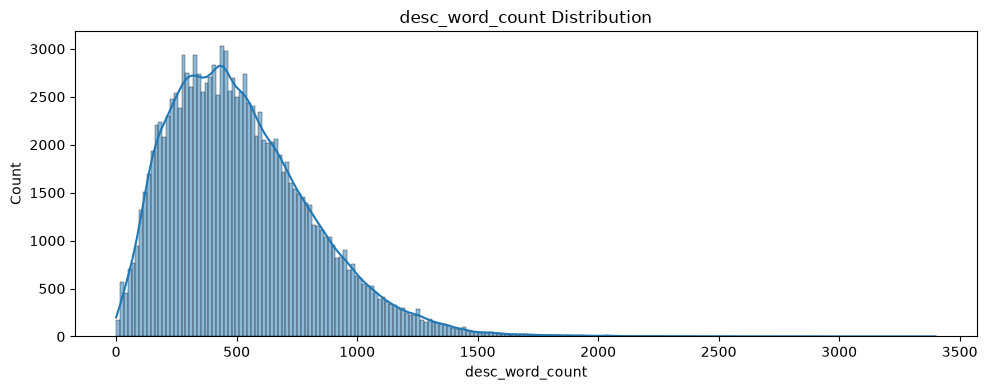

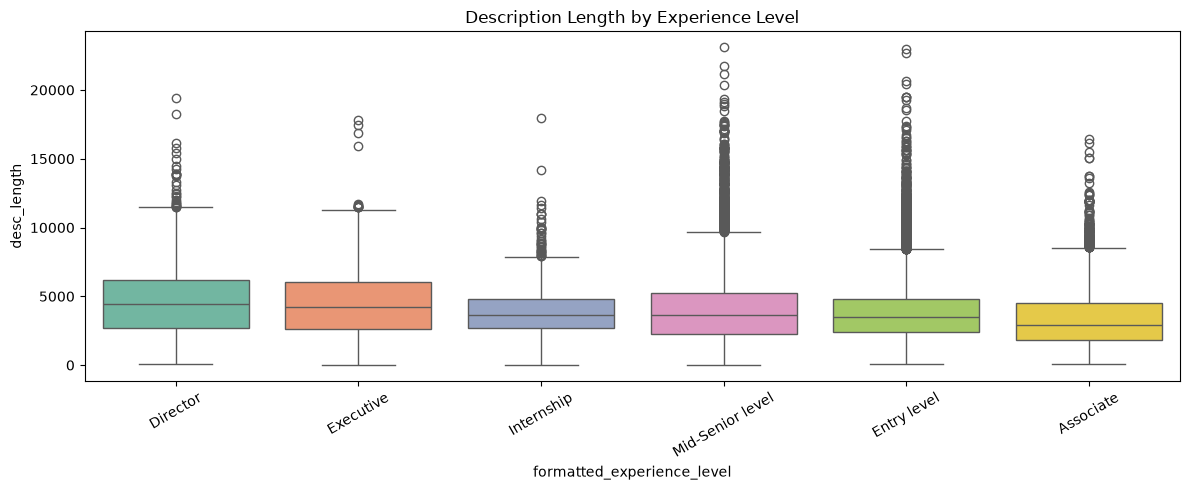

In [268]:
if 'title' in df.columns:
    df['title_length'] = df['title'].fillna('').str.len()
if 'description' in df.columns:
    df['desc_length'] = df['description'].fillna('').str.len()
    df['desc_word_count'] = df['description'].fillna('').str.split().str.len()

text_cols = [c for c in ['title_length', 'desc_length', 'desc_word_count'] if c in df.columns]

for col in text_cols:
    plt.figure(figsize=(10, 4))
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f'{col} Distribution')
    plt.tight_layout()
    plt.show()

# Description length by experience level
if TARGET in df.columns and 'desc_length' in df.columns:
    plot_df = df[[TARGET, 'desc_length']].dropna()
    order = plot_df.groupby(TARGET)['desc_length'].median().sort_values(ascending=False).index
    
    plt.figure(figsize=(12, 5))
    sns.boxplot(data=plot_df, x=TARGET, y='desc_length', order=order, palette='Set2')
    plt.title('Description Length by Experience Level')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

## Feature Evaluation Summary (4-Panel Overview)

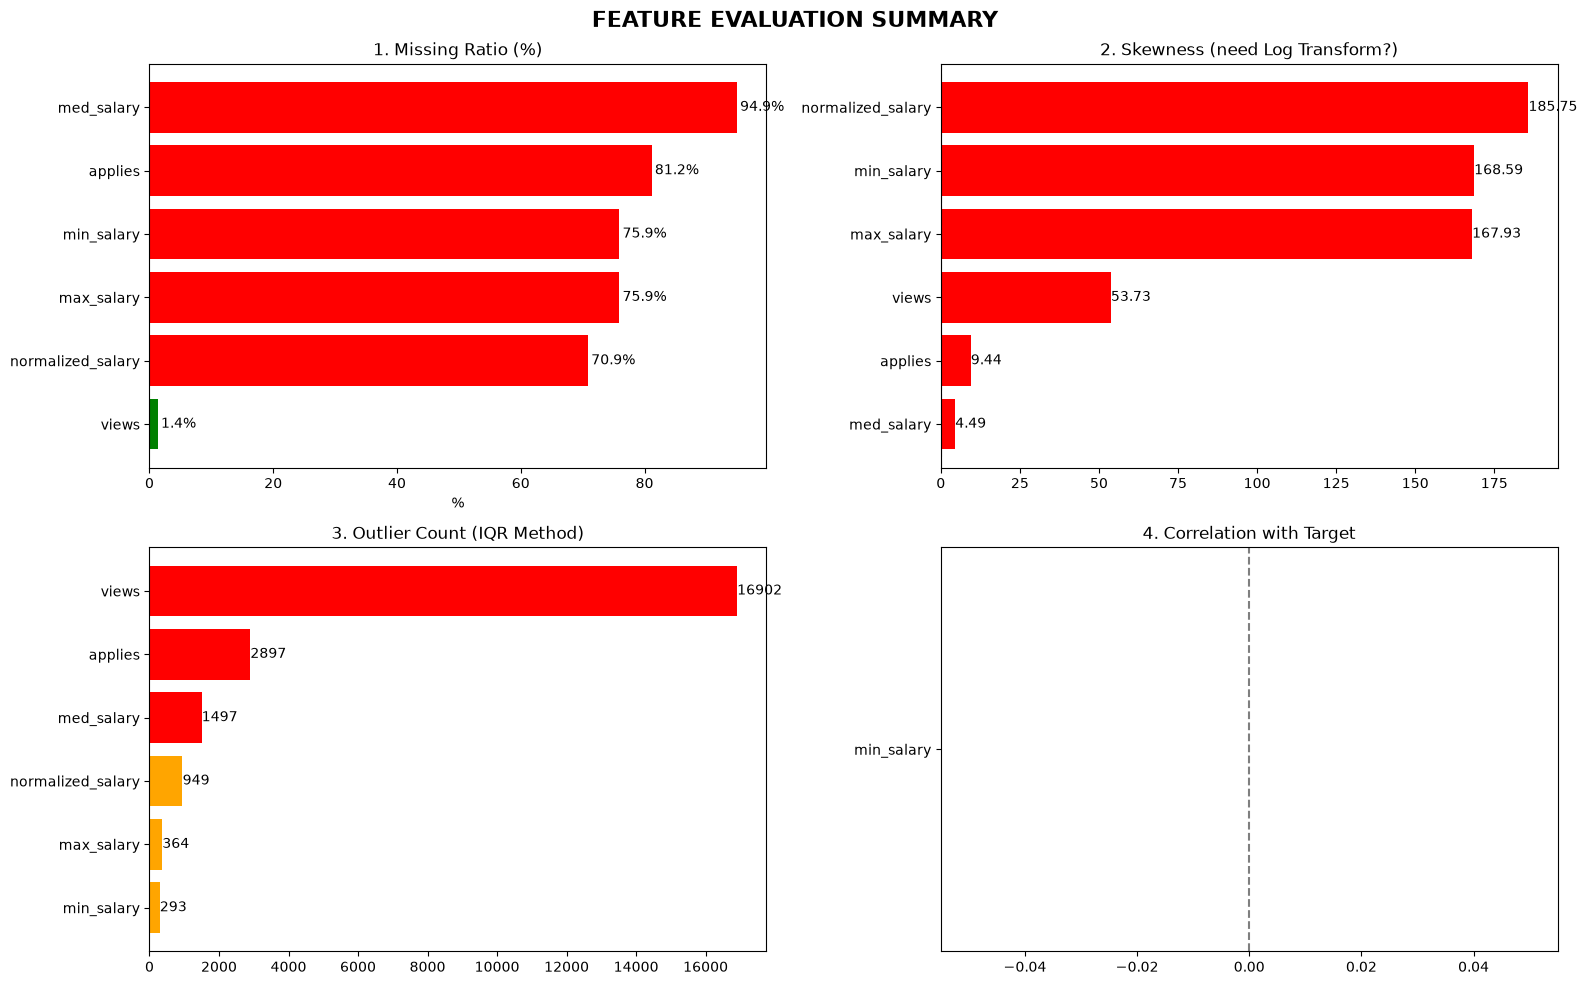

>>> RECOMMENDATIONS:
    GREEN  = Good, keep as-is
    ORANGE = Warning, needs treatment
    RED    = Critical, consider dropping or heavy transformation

    min_salary: missing=76%, skew=168.6 -> log transform
    med_salary: missing=95%, skew=4.5 -> log transform, outliers=1497
    max_salary: missing=76%, skew=167.9 -> log transform
    normalized_salary: missing=71%, skew=185.8 -> log transform
    views: skew=53.7 -> log transform, outliers=16902
    applies: missing=81%, skew=9.4 -> log transform, outliers=2897


In [269]:
eval_cols = [c for c in ['min_salary', 'med_salary', 'max_salary',
                          'normalized_salary', 'views', 'applies']
             if c in df.columns]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# --- 1. Missing Ratio (%) ---
missing = (df[eval_cols].isnull().sum() / len(df) * 100).sort_values(ascending=True)
colors_m = ['red' if v > 50 else 'orange' if v > 20 else 'green' for v in missing]
axes[0, 0].barh(missing.index, missing.values, color=colors_m)
axes[0, 0].set_title('1. Missing Ratio (%)')
axes[0, 0].set_xlabel('%')
for i, v in enumerate(missing.values):
    axes[0, 0].text(v + 0.5, i, f'{v:.1f}%', va='center')

# --- 2. Skewness ---
skew = df[eval_cols].skew().sort_values(ascending=True)
colors_s = ['red' if abs(v) > 2 else 'orange' if abs(v) > 1 else 'green' for v in skew]
axes[0, 1].barh(skew.index, skew.values, color=colors_s)
axes[0, 1].set_title('2. Skewness (need Log Transform?)')
axes[0, 1].axvline(x=0, color='black', linestyle='--', alpha=0.5)
for i, v in enumerate(skew.values):
    axes[0, 1].text(v + 0.05, i, f'{v:.2f}', va='center')

# --- 3. Outlier Count (IQR method) ---
outlier_counts = {}
for col in eval_cols:
    data = df[col].dropna()
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    outlier_counts[col] = ((data < q1 - 1.5*iqr) | (data > q3 + 1.5*iqr)).sum()
oc = pd.Series(outlier_counts).sort_values(ascending=True)
colors_o = ['red' if v > 1000 else 'orange' if v > 100 else 'green' for v in oc]
axes[1, 0].barh(oc.index, oc.values, color=colors_o)
axes[1, 0].set_title('3. Outlier Count (IQR Method)')
for i, v in enumerate(oc.values):
    axes[1, 0].text(v + 5, i, str(v), va='center')

# --- 4. Correlation with Target (encoded) ---
if TARGET in df.columns:
    temp = df[eval_cols + [TARGET]].dropna()
    temp['target_enc'] = temp[TARGET].astype('category').cat.codes
    corr_target = temp[eval_cols].corrwith(temp['target_enc']).sort_values(ascending=True)
    colors_t = ['green' if abs(v) > 0.3 else 'orange' if abs(v) > 0.1 else 'gray' for v in corr_target]
    axes[1, 1].barh(corr_target.index, corr_target.values, color=colors_t)
    axes[1, 1].set_title('4. Correlation with Target')
    axes[1, 1].axvline(x=0, color='black', linestyle='--', alpha=0.5)
    for i, v in enumerate(corr_target.values):
        axes[1, 1].text(v + 0.01, i, f'{v:.3f}', va='center')

plt.suptitle('FEATURE EVALUATION SUMMARY', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print('>>> RECOMMENDATIONS:')
print('    GREEN  = Good, keep as-is')
print('    ORANGE = Warning, needs treatment')
print('    RED    = Critical, consider dropping or heavy transformation')
print()
for col in eval_cols:
    issues = []
    m = df[col].isnull().sum() / len(df) * 100
    s = abs(df[col].skew()) if df[col].notna().sum() > 0 else 0
    o = outlier_counts.get(col, 0)
    if m > 50: issues.append('missing=' + str(round(m)) + '%')
    if s > 2: issues.append('skew=' + str(round(s,1)) + ' -> log transform')
    if o > 1000: issues.append('outliers=' + str(o))
    if not issues:
        print('    ' + col + ': OK')
    else:
        print('    ' + col + ': ' + ', '.join(issues))

## 12. Business Insights & Executive Dashboard

In [270]:
print('=' * 60)
print('       BUSINESS INSIGHTS - DS JOB RECOMMEND')
print('=' * 60)

if TARGET in df.columns:
    counts = df[TARGET].value_counts()
    print(f'\n1. Most posted level: {counts.idxmax()} ({counts.max():,} postings)')
    print(f'   Least posted level: {counts.idxmin()} ({counts.min():,} postings)')

if sal_col and TARGET in df.columns:
    by_level = df.groupby(TARGET)[sal_col].median().sort_values(ascending=False)
    print(f'\n2. Median salary by level:')
    for level, val in by_level.items():
        print(f'   {level}: ${val:,.0f}')

print(f'\n3. Multicollinearity: Salary columns are highly correlated')
print(f'   -> Keep only normalized_salary for modeling')

print(f'\n4. Class imbalance ratio: {counts.max()/counts.min():.0f}:1')
print(f'   -> Must use SMOTE or class_weight')
print('=' * 60)

       BUSINESS INSIGHTS - DS JOB RECOMMEND

1. Most posted level: Mid-Senior level (41,489 postings)
   Least posted level: Executive (1,222 postings)

2. Median salary by level:
   Executive: $193,750
   Director: $167,500
   Mid-Senior level: $108,389
   Associate: $74,880
   Entry level: $52,442
   Internship: $47,840

3. Multicollinearity: Salary columns are highly correlated
   -> Keep only normalized_salary for modeling

4. Class imbalance ratio: 34:1
   -> Must use SMOTE or class_weight


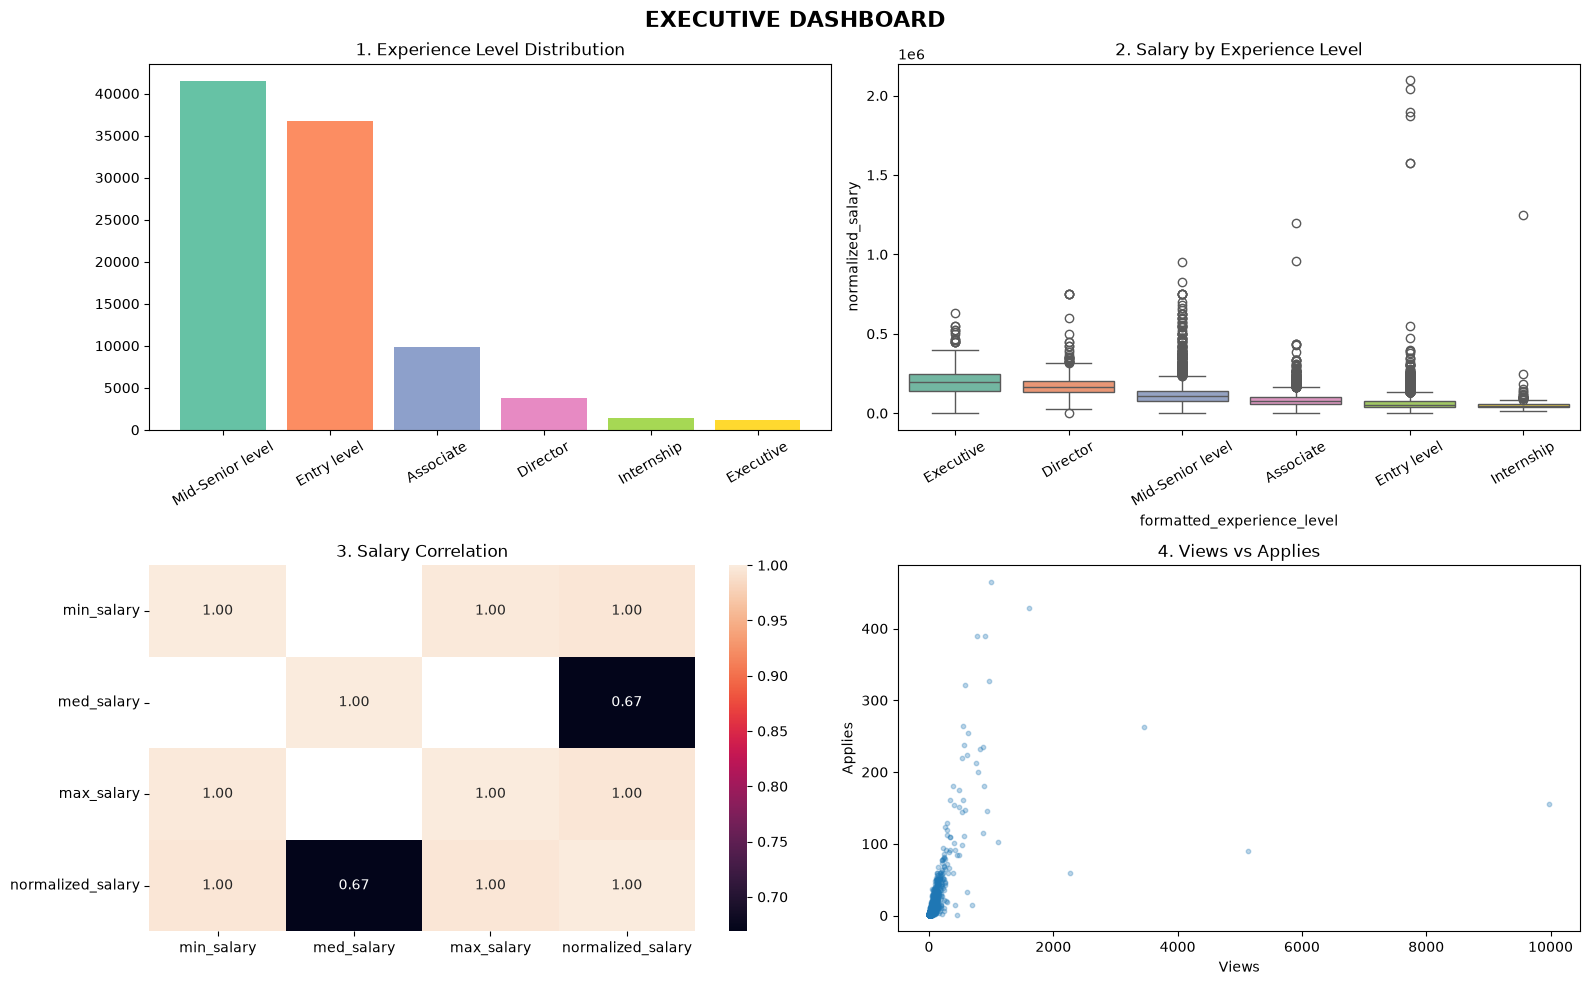


Exploratory Data Analysis completed!


In [271]:
if sal_col and TARGET in df.columns:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # 1. Target Distribution
    target_counts = df[TARGET].dropna().value_counts()
    axes[0, 0].bar([str(x) for x in target_counts.index], target_counts.values, color=sns.color_palette('Set2'))
    axes[0, 0].set_title('1. Experience Level Distribution')
    axes[0, 0].tick_params(axis='x', rotation=30)
    
    # 2. Salary by Level
    order = df.groupby(TARGET)[sal_col].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=TARGET, y=sal_col, order=order, palette='Set2', ax=axes[0, 1])
    axes[0, 1].set_title('2. Salary by Experience Level')
    axes[0, 1].tick_params(axis='x', rotation=30)
    
    # 3. Correlation Heatmap
    sal_cols = [c for c in ['min_salary', 'med_salary', 'max_salary', 'normalized_salary']
                if c in df.columns]
    if len(sal_cols) >= 2:
        sns.heatmap(df[sal_cols].corr(), annot=True, fmt='.2f', ax=axes[1, 0])
        axes[1, 0].set_title('3. Salary Correlation')
    
    # 4. Views vs Applies
    if 'views' in df.columns and 'applies' in df.columns:
        va = df[['views', 'applies']].dropna().sample(min(2000, len(df)), random_state=42)
        axes[1, 1].scatter(va['views'], va['applies'], alpha=0.3, s=10)
        axes[1, 1].set_title('4. Views vs Applies')
        axes[1, 1].set_xlabel('Views')
        axes[1, 1].set_ylabel('Applies')
    
    plt.suptitle('EXECUTIVE DASHBOARD', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

print('\nExploratory Data Analysis completed!')